_Neural Data Science_

Lecturer: Dr. Jan Lause, Prof. Dr. Philipp Berens

Tutors: Jonas Beck, Fabio Seel, Julius Würzler

Summer term 2025

Student names: Luca Kosina, Sascha Mühlinghaus, Max Bardelang

LLM Disclaimer: Copilot for generating repetitive code in plotting , boilerplate code and nasty indexing tasks

# Neural Data Science Project 01

## Working with Calcium data

In the following project you will recieve a data set, along with a set of questions. Use the methods that you have learned throughout this course to explore the data and to answer the questions. You are free to use tools, resources and libraries as you see fit. Use comments and markdown cells to document your thought process and to explain your reasoning. We encourage you to compare different algorithms or to implement state of the art solutions. The notebook should be self contained, although you may offload some functions to a `utils.py`. The notebook should be concluded with a final summary / conclusions section.

In [ ]:
# import packages here

import numpy as np
import pandas as pd
import jupyter_black
import scipy
import oopsi
import matplotlib.pyplot as plt

jupyter_black.load()
scipy.__version__

'1.13.0'

## Context
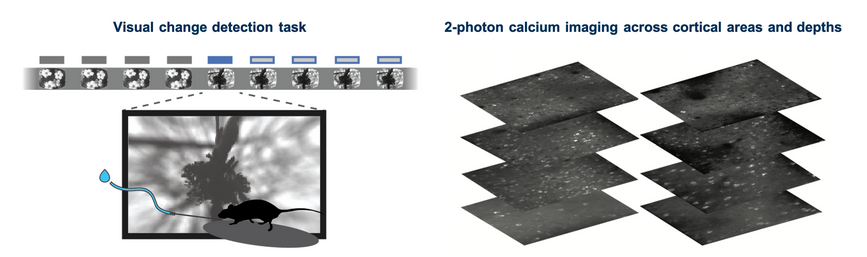

The data set that goes along with this notebook was recorded using in vivo 2-photon calcium imaging to measure the activity of genetically identified neurons in the visual cortex of mice performing a go/no-go visual change detection task. The data recordings stem from primary visual cortex and a GCaMP6f indicator was used. The data was recorded as follows.

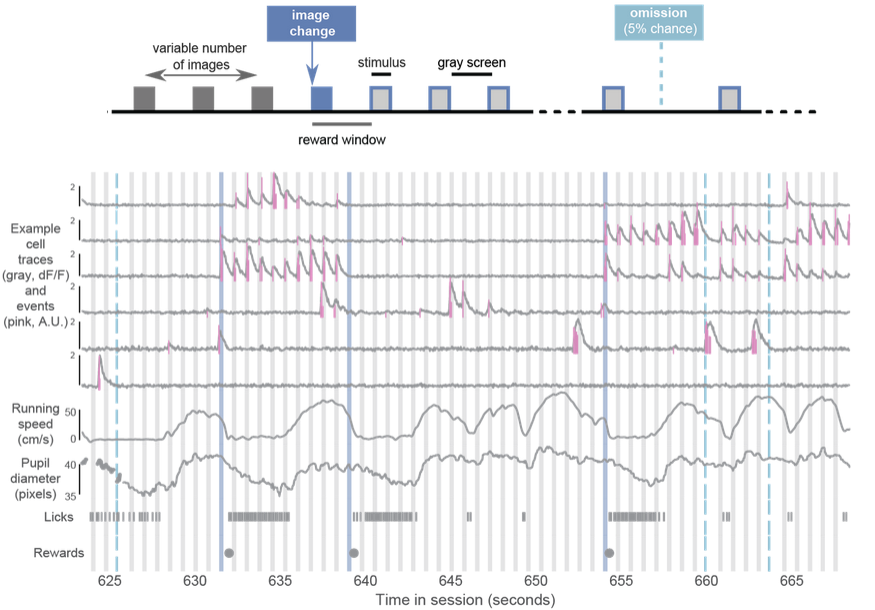

The data consists of:
- the preprocessed activity traces (df/f)
- the stimulus metadata
- the ROI masks for each cell
- a maximum activity projection of the recorded area
- running speed
- table of stimulus epochs

You will only work with a drifting grating stimulus.

Since the experiments were performed in sequence the calcium recordings that you receive also contain some other stimulus modalities (see `data["stim_epoch_table"]`). You can ignore these sections of the time-series data during analysis. Not all the data provided has to be used, however it can be incorporated into your analysis.

In [ ]:
# load data
def load_data(path="."):
    def array2df(d, key, cols):
        d[key] = pd.DataFrame(d[key], columns=cols)

    data = np.load(path + "/dff_data_dsi.npz", allow_pickle=True)
    data = dict(data)
    array2df(
        data,
        "stim_table",
        ["frequency", "direction", "blank_sweep", "start", "end"],
    )
    array2df(data, "stim_epoch_table", ["stimulus", "start", "end"])

    return data


def print_info(data):
    data_iter = ((k, type(v), v.shape) for k, v in data.items())
    l = [f"[{k}] - {t}, - {s}" for k, t, s in data_iter]
    print("\n".join(l) + "\n")


data = load_data()

print("Overview of the data")
print_info(data)

Overview of the data
[t] - <class 'numpy.ndarray'>, - (115471,)
[dff] - <class 'numpy.ndarray'>, - (106, 115471)
[stim_table] - <class 'pandas.core.frame.DataFrame'>, - (628, 5)
[roi_masks] - <class 'numpy.ndarray'>, - (106, 512, 512)
[max_projection] - <class 'numpy.ndarray'>, - (512, 512)
[running_speed] - <class 'numpy.ndarray'>, - (2, 115471)
[stim_epoch_table] - <class 'pandas.core.frame.DataFrame'>, - (7, 3)



## Question

**Is there spatial structure in the preferred orientation/direction/frequency?**

Implement all steps of the processing pipeline that are necessary to answer them. Think of: 
1. Pre-processing 
2. Spike inference 
3. Tuning function fitting 
4. Statistical testing. 

It is sufficient to assess spatial structure visually. Additional insights and analyses will be positively factored into the overall grade.

# Implementation

## EDA

we try different spike interference methods and compare them. since in their original papers, each spike interference method uses a different pipeline, we also utilize different preprocessing pipelines accordingly here.

In [ ]:
dff = data["dff"]
t = data["t"]
stim = data["stim_table"]
set = data["stim_epoch_table"]

segment data. this has to be done before subselecting data, as otherwise indices become invalid

In [ ]:
stim

,frequency,direction,blank_sweep,start,end
0,1.0,225.0,0.0,747.0,807.0
1,2.0,180.0,0.0,837.0,897.0
2,4.0,90.0,0.0,927.0,987.0
3,1.0,270.0,0.0,1018.0,1077.0
4,4.0,135.0,0.0,1108.0,1168.0
...,...,...,...,...,...
623,4.0,315.0,0.0,114794.0,114854.0
624,2.0,45.0,0.0,114884.0,114944.0
625,4.0,180.0,0.0,114975.0,115034.0
626,4.0,270.0,0.0,115065.0,115125.0


In [ ]:
dff_trials = [dff[:, int(row.start) : int(row.end)] for _, row in stim.iterrows()]

select data for drifting_gradients

In [ ]:
stim

,frequency,direction,blank_sweep,start,end
0,1.0,225.0,0.0,747.0,807.0
1,2.0,180.0,0.0,837.0,897.0
2,4.0,90.0,0.0,927.0,987.0
3,1.0,270.0,0.0,1018.0,1077.0
4,4.0,135.0,0.0,1108.0,1168.0
...,...,...,...,...,...
623,4.0,315.0,0.0,114794.0,114854.0
624,2.0,45.0,0.0,114884.0,114944.0
625,4.0,180.0,0.0,114975.0,115034.0
626,4.0,270.0,0.0,115065.0,115125.0


In [ ]:
# get length of trials by
trial_length = np.array([row.end - row.start for _, row in stim.iterrows()])
np.unique(trial_length)

array([59., 60., 61.])

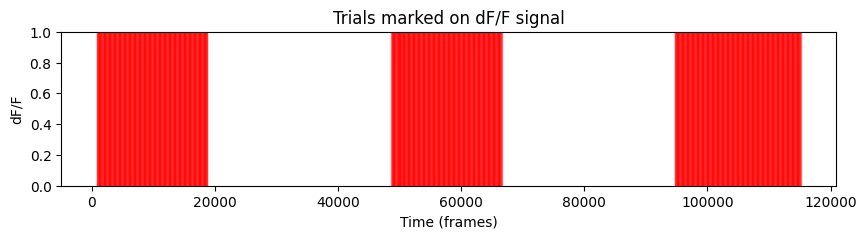

In [ ]:
# mark trials on a time axis
import matplotlib.pyplot as plt


def mark_trials(ax, stim_table, color="red", alpha=0.5):
    for _, row in stim_table.iterrows():
        ax.axvspan(row.start, row.end, color=color, alpha=alpha)


fig, ax = plt.subplots(figsize=(10, 2))
mark_trials(ax, stim, color="red", alpha=0.5)
ax.set_xlabel("Time (frames)")
ax.set_ylabel("dF/F")
ax.set_title("Trials marked on dF/F signal")
plt.show()

In [ ]:
set

,stimulus,start,end
0,drifting_gratings,747,18775
1,natural_movie_three,19709,37767
2,natural_movie_one,38671,47699
3,drifting_gratings,48602,66630
4,spontaneous,66780,75697
5,natural_movie_three,75698,93756
6,drifting_gratings,94659,115215


In [ ]:
def is_drifting_grating(start, end):
    return (
        ((start > 747) and (end < 18775))
        or ((start > 48602) and (end < 66630))
        or ((start > 94659) and (end < 115215))
    )

In [ ]:
# check from information in stim table, if corresponding trial is a drifting grating stimulus while selecting trials from dff_trials
dff_dsi = [
    trial
    for trial, sti in zip(dff_trials, stim.itertuples())
    if is_drifting_grating(sti.start, sti.end)
]

In [ ]:
len(dff_trials)

628

In [ ]:
len(dff_dsi)

622

## Pre-processing and spike-interference

### oopsie

In [ ]:
dff_trials[0].shape

(106, 60)

<matplotlib.legend.Legend>

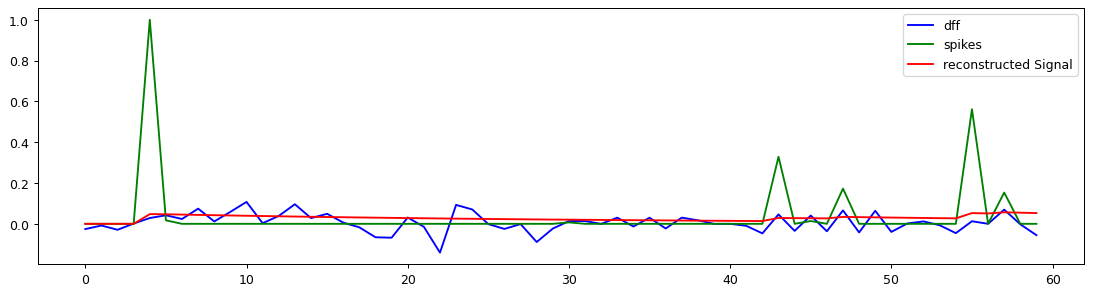

In [ ]:
trial = dff_trials[0][6]
d, Cz = oopsi.fast(trial, dt=0.0333, iter_max=10)
# create figure
fig = plt.figure(num=None, figsize=(15, 17), dpi=90, facecolor="w", edgecolor="k")
# fig = plt.figure()

# create subplot
ax2 = fig.add_subplot(412)
ax2.plot(trial, color="blue", linewidth=1.5, label="dff")
ax2.plot(d, color="green", linewidth=1.5, label="spikes")
ax2.plot(Cz, color="red", linewidth=1.5, label="reconstructed Signal")
ax2.legend(loc="upper right")

**preprocessing**

In [ ]:
from scipy.fft import fft, ifft, fftfreq
from scipy.signal import butter, filtfilt


def highpass_filter(trace, fs=30, cutoff=0.5):
    """
    trace: input 1D signal
    fs: sampling frequency (Hz)
    cutoff: cutoff frequency (Hz)
    Returns: highpass filtered signal (same length)
    """
    N = len(trace)
    f = fftfreq(N, d=1 / fs)
    trace_fft = fft(trace)
    # Set all frequency components below cutoff to zero
    trace_fft[np.abs(f) < cutoff] = 0
    return np.real(ifft(trace_fft))


def butter_highpass_filter(trace, fs=30, cutoff=0.5, order=4):
    """
    Butterworth highpass filter for 1D signal.
    trace: input 1D signal
    fs: sampling frequency (Hz)
    cutoff: cutoff frequency (Hz)
    order: filter order
    Returns: filtered signal
    """
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype="high", analog=False)
    filtered = filtfilt(b, a, trace)
    return filtered


def normalize_trace(trace):
    f_min = np.min(trace)
    f_max = np.max(trace)
    if f_max == f_min:
        return np.zeros_like(trace)
    return (trace - f_min) / (f_max - f_min)

[<matplotlib.lines.Line2D>]

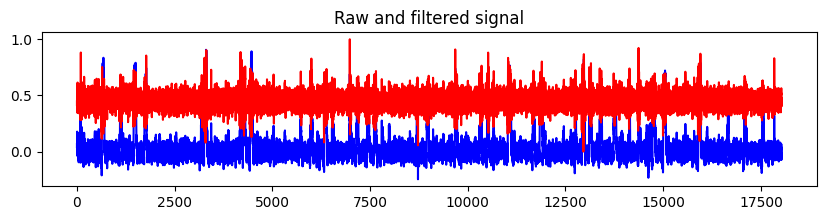

In [ ]:
data1 = dff[42]  # subselect single neuron
#raw = data1[747:18775]  # subselect first 10000 frames
raw = data1[48602:66630]  # subselect first 10000 frames
data1 = butter_highpass_filter(raw, fs=30, cutoff=0.5)
data1 = normalize_trace(data1)

# plot raw and filtered signal
fig, ax = plt.subplots(1, 1, figsize=(10, 2), sharex=True)
ax.set_title("Raw and filtered signal")
ax.plot(raw, linewidth=1.5, color="blue")
ax.plot(data1, linewidth=1.5, color="red")

<matplotlib.legend.Legend>

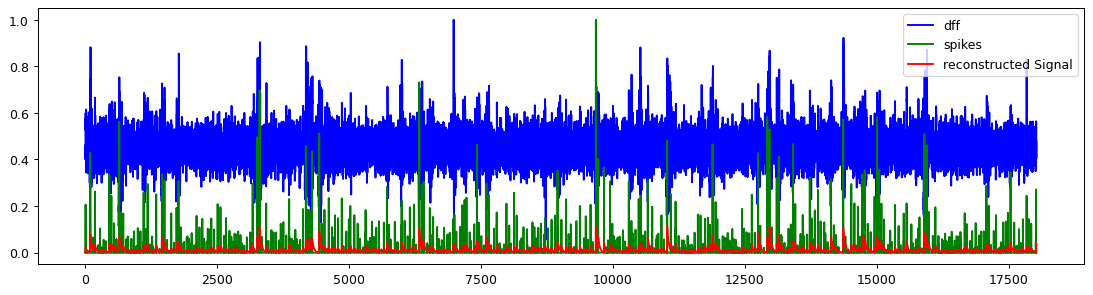

In [ ]:
d, Cz = oopsi.fast(data1, dt=0.0333, iter_max=10)

# create figure
fig = plt.figure(num=None, figsize=(15, 17), dpi=90, facecolor="w", edgecolor="k")

# create subplot
ax2 = fig.add_subplot(412)
ax2.plot(data1, color="blue", linewidth=1.5, label="dff")
ax2.plot(d, color="green", linewidth=1.5, label="spikes")
ax2.plot(Cz, color="red", linewidth=1.5, label="reconstructed Signal")
ax2.legend(loc="upper right")

<matplotlib.legend.Legend>

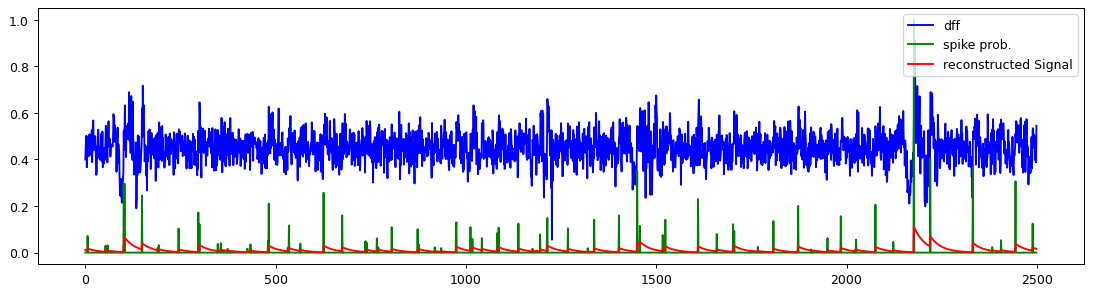

In [ ]:
# create subplot
a, e = 7500, 10000

fig = plt.figure(num=None, figsize=(15, 17), dpi=90, facecolor="w", edgecolor="k")
ax2 = fig.add_subplot(412)
ax2.plot(data1[a:e], color="blue", linewidth=1.5, label="dff")
ax2.plot(d[a:e], color="green", linewidth=1.5, label="spike prob.")
ax2.plot(Cz[a:e], color="red", linewidth=1.5, label="reconstructed Signal")
ax2.legend(loc="upper right")

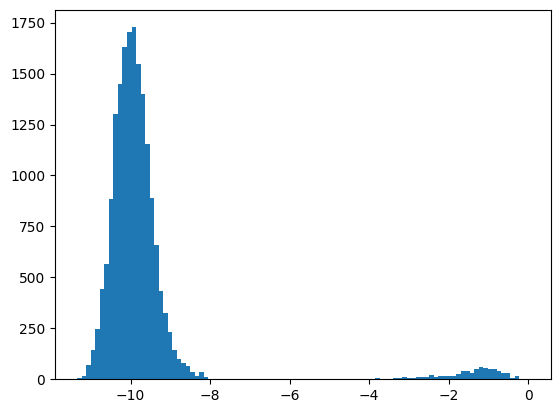

In [ ]:
plt.hist(np.log10(d), bins=100);

In [ ]:
spikes = np.log10(d) > -5

### oopsi on whole dataset

#### build DataFrame

In [ ]:
def build_dff_dataframe(dff, stims, stim_epoch_table):
    """
    builds a dataframe containing dff traces matched to stimulation trials.
    only includes trials that fall within drifting grating stimulus epochs.

    parameters:
    - dff: array of shape (neurons, frames), containing dff signal values
    - stims: dataframe with columns 'start', 'end', 'frequency', 'direction', 'blank_sweep'
             each row represents a trial
    - stim_epoch_table: dataframe with columns 'stimulus', 'start', 'end'

    returns:
    - dff_df: dataframe with trial-aligned dff data
    """

    # convert start and end columns to integers
    stim_epoch_table["start"] = stim_epoch_table["start"].astype(int)
    stim_epoch_table["end"] = stim_epoch_table["end"].astype(int)
    stims["start"] = stims["start"].astype(int)
    stims["end"] = stims["end"].astype(int)

    # get only drifting gratings epochs
    drifting_epochs = stim_epoch_table[
        stim_epoch_table["stimulus"] == "drifting_gratings"
    ].reset_index(drop=True)

    # create interval index for drifting grating epochs
    epoch_intervals = pd.IntervalIndex.from_arrays(
        drifting_epochs["start"], drifting_epochs["end"], closed="both"
    )

    records = []

    for trial_number, stim in stims.iterrows():
        start, end = stim["start"], stim["end"]

        start = int(stim["start"])
        end = int(stim["end"])

        # check if trial is fully within a drifting grating epoch
        epoch_match = epoch_intervals.contains(start) & epoch_intervals.contains(end)
        if not any(epoch_match):
            continue

        epoch_id = epoch_match.argmax()

        frequency = stim["frequency"]
        direction = stim["direction"]
        blank_sweep = stim["blank_sweep"]

        for neuron_idx in range(dff.shape[0]):
            trial_dff = dff[neuron_idx, start : end + 1]
            rel_times = np.arange(0, end - start + 1)
            frame_indices = np.arange(start, end + 1)

            for f_idx, rel_time, dff_val in zip(frame_indices, rel_times, trial_dff):
                records.append(
                    {
                        "Neuron": neuron_idx,
                        "Trial": trial_number,
                        "Epoch": epoch_id,
                        "FrameIdx": f_idx,
                        "Frequency": frequency,
                        "BlankSweep": blank_sweep,
                        "Dir": direction,
                        "relTime": rel_time,
                        "DFF": dff_val,
                    }
                )

    dff_df = pd.DataFrame.from_records(records)

    return dff_df

In [ ]:
stim_table = data["stim_table"]
stim_epoch_table = data["stim_epoch_table"]


dff_df = build_dff_dataframe(
    data["dff"],
    stim_table,
    stim_epoch_table,
)

# exclude trials with blank sweeps
dff_df = dff_df[dff_df["BlankSweep"].astype(int).values == 0]

In [ ]:
# add 1 to values of Neuron, Trial and Epoch
dff_df["Neuron"] = dff_df["Neuron"].values + 1
dff_df["Trial"] = dff_df["Trial"].values + 1
dff_df["Epoch"] = dff_df["Epoch"].values + 1
dff_df

,Neuron,Trial,Epoch,FrameIdx,Frequency,BlankSweep,Dir,relTime,DFF
0,1,1,1,747,1.0,0.0,225.0,0,0.059512
1,1,1,1,748,1.0,0.0,225.0,1,-0.000203
2,1,1,1,749,1.0,0.0,225.0,2,-0.041120
3,1,1,1,750,1.0,0.0,225.0,3,-0.098806
4,1,1,1,751,1.0,0.0,225.0,4,-0.028460
...,...,...,...,...,...,...,...,...,...
4040397,106,628,3,115211,1.0,0.0,180.0,56,-0.018237
4040398,106,628,3,115212,1.0,0.0,180.0,57,-0.000033
4040399,106,628,3,115213,1.0,0.0,180.0,58,-0.077658
4040400,106,628,3,115214,1.0,0.0,180.0,59,0.000000


In [ ]:
df = dff_df

In [ ]:
# group by Neuron and epoch and apply oopsie.fast to each group
def apply_oopsi(group):
    d, Cz = oopsi.fast(group["DFF"].values, dt=0.0333, iter_max=6)
    group["Spikes"] = d
    group["Cz"] = Cz
    return group
dff_df = dff_df.groupby(["Neuron", "Epoch"]).apply(apply_oopsi).reset_index(drop=True)

### OASIS

In [ ]:
from oasis.functions import (
    deconvolve,
    estimate_parameters,
)
#from oasis.plotting import simpleaxis


import numpy as np
import pandas as pd
#import jupyter_black
import matplotlib.pyplot as plt


#jupyter_black.load()

In [ ]:
y = data["dff"][0]
%time c, deconv, b, g, lam = deconvolve(y, penalty=1)

In [ ]:
plt.plot(range(4))

## Tuning function  fitting

## Statistical testing